In [1]:
import numpy as np
import json
import torch
from matplotlib import pyplot as plt
from pathlib import Path

from utils.general_functions import real_imag_to_mag_db_ph_deg, complex_to_mag_db_ph_deg, transfer_function, generate_masks

In [2]:
N = 512
freq_lim = [10.0, 100e3]

freq = np.linspace(freq_lim[0], freq_lim[-1], N)

gain_complex = transfer_function(
    freq=freq,
    zero_poles=int(0),
    poles=[],
    zeros=[10e3]
)

In [3]:
user_figsize = (12, 8)
user_fontsize = 14
user_ylabel = ['Magnitude, dB', 'Phase, deg']

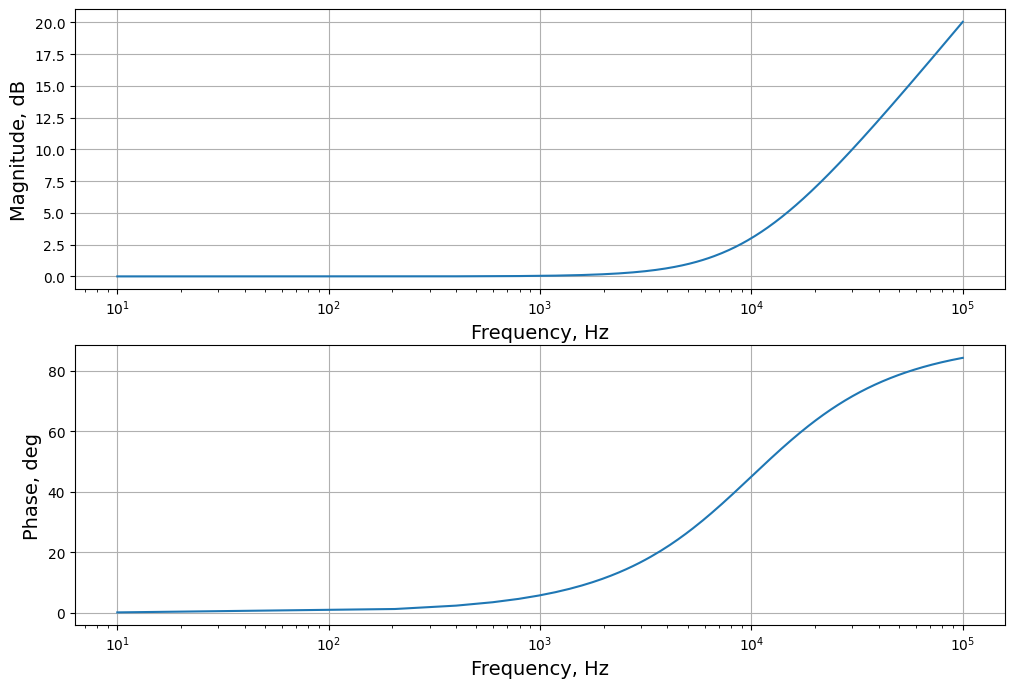

In [4]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=user_figsize)
mag_ph_dataset = complex_to_mag_db_ph_deg(gain_complex)

for idx, ax in enumerate(axs):
    ax.plot(np.linspace(freq_lim[0], freq_lim[-1], N), mag_ph_dataset[idx])
    ax.set_xlabel('Frequency, Hz', fontsize=user_fontsize)
    ax.set_ylabel(user_ylabel[idx], fontsize=user_fontsize)
    ax.axes.grid(True)
    ax.set_xscale('log')
plt.show()

In [5]:
config_dir = Path("./config/")
dataset_dir = Path('./dataset/')

In [6]:
config_path = config_dir / "config.json"
assert config_path.exists(), f"Config not found: {config_path}"
with open(config_path, "r") as f:
    configer = json.load(f)

masks = generate_masks(masks={}, configer=configer)
print(masks["1zp2lp1rp2lz1rz_001"])

{'zero_poles': 1, 'left_poles': [44, 230], 'right_poles': [355], 'left_zeros': [433, 144], 'right_zeros': [234]}


In [7]:
if torch.cuda.is_available():
    print("CUDA is available!")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version used by PyTorch: {torch.version.cuda}")
else:
    print("CUDA is not available. PyTorch is using CPU.")

CUDA is not available. PyTorch is using CPU.


## Dataloader

In [ ]:
user_fontsize = 14
user_ylabel = ['Magnitude, dB', 'Phase, deg']
user_colors = ['skyblue', 'salmon']
bar_width = 2.0

In [8]:
N_samples = 4
split = configer['split']

mask_path = Path(dataset_dir) / (split + "_masks.json")
assert mask_path.exists(), f"Mask not found: {mask_path}"
with open(mask_path, "r") as f:
    masks = json.load(f)
    
samples_full = list(masks.keys())
samples = np.random.choice(samples_full, size=N_samples, replace=False).tolist()

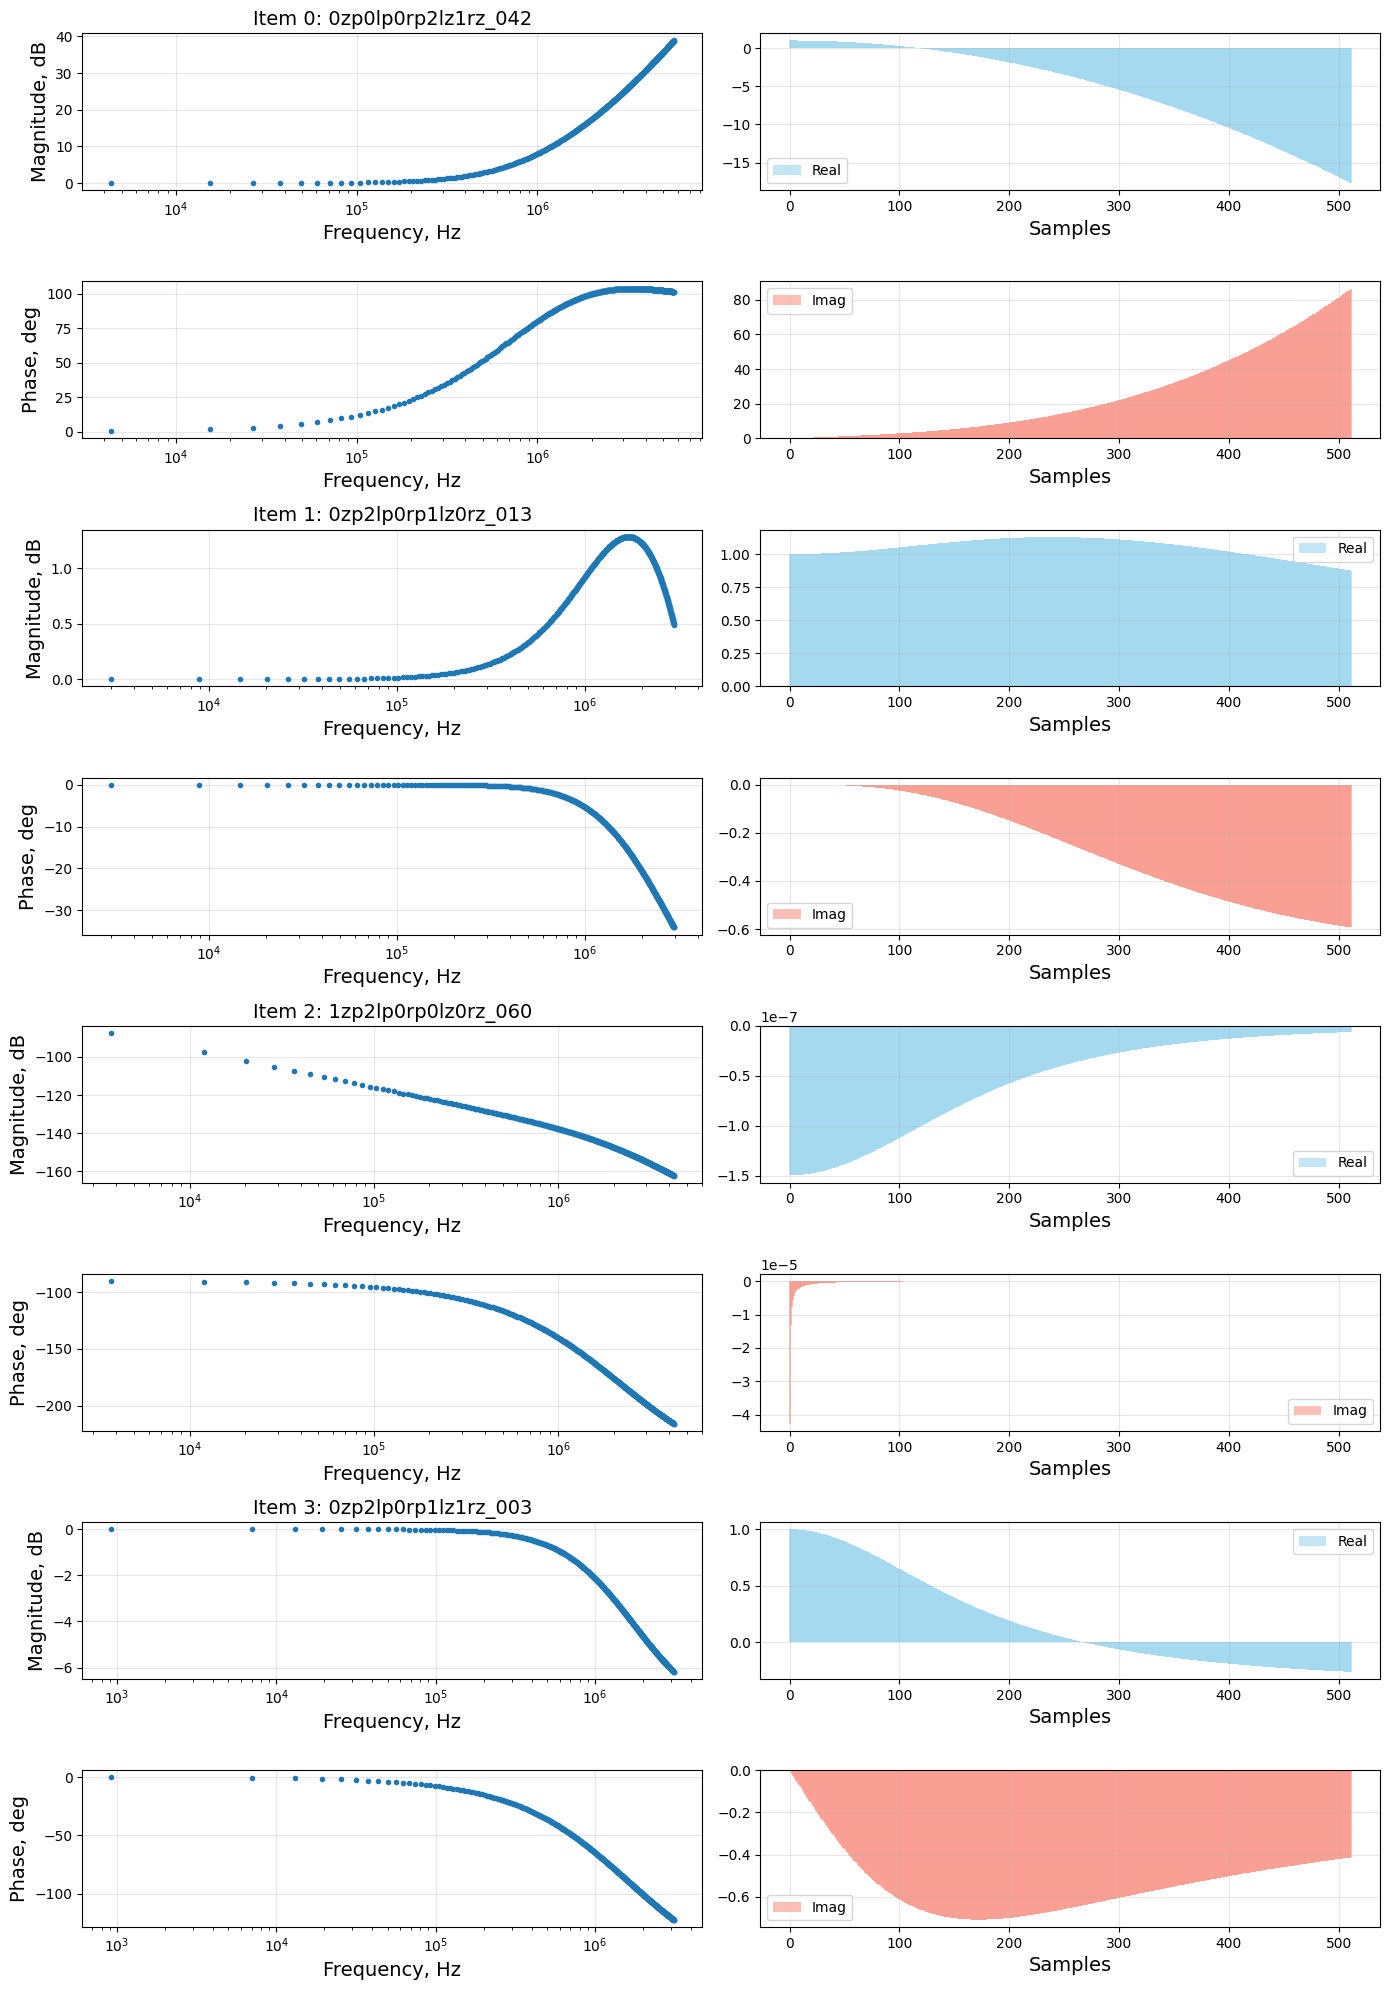

In [12]:
from utils.ZerosPolesDataset import ZerosPolesDataset

dataset = ZerosPolesDataset(
    dataset_dir = dataset_dir,
    split = configer['split'],
    samples=samples
)

from utils.settings import var

x_samples = np.array(range(N))

fig, axs = plt.subplots(nrows=2*N_samples, ncols=2, figsize=(14,N_samples*5))
axs = axs.flatten()

for k in range(N_samples):
    data_tensor, masks_tensor, freq = dataset.__getitem__(k)
    data_real_imag = data_tensor.numpy()
    data_mag_db, data_ph_deg = real_imag_to_mag_db_ph_deg(data_real_imag[:,0], data_real_imag[:,1])

    data = np.column_stack([freq, data_mag_db, data_ph_deg])
    
    for idx in range(4):
        ax = axs[k*4+idx]
        if idx == 0:
            ax.plot(data[:, var.freq.value], data[:, var.mag_db.value], 'o', markersize=3, linestyle='')
            ax.set_ylabel(user_ylabel[0], fontsize=user_fontsize)
            ax.set_xscale('log')
            ax.set_xlabel('Frequency, Hz', fontsize=user_fontsize)
            ax.set_title(f"Item {k}: {samples[k]}", fontsize=user_fontsize)
        elif idx == 1:
            ax.bar(x_samples, data_real_imag[:,0], width=bar_width, label='Real', color=user_colors[0], alpha=0.5)
            ax.legend()
            ax.set_xlabel('Samples', fontsize=user_fontsize)
        elif idx == 2:
            ax.plot(data[:, var.freq.value], data[:, var.ph_deg.value], 'o', markersize=3, linestyle='')
            ax.set_ylabel(user_ylabel[1], fontsize=user_fontsize)
            ax.set_xscale('log')
            ax.set_xlabel('Frequency, Hz', fontsize=user_fontsize)
        elif idx == 3:
            ax.bar(x_samples, data_real_imag[:,1], width=bar_width, label='Imag', color=user_colors[1], alpha=0.5)
            ax.legend()
            ax.set_xlabel('Samples', fontsize=user_fontsize)
        ax.axes.grid(True, alpha=0.3)
    
plt.tight_layout()
plt.show()